<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
unit: Unit 2 — Classical Machine Learning Algorithms
submodule: 2.1 Supervised Learning — Regression Models
scheduled_sessions: Sessions 09 & 10 (Day 09/10)
document_type: Practical Laboratory Notebook
ai_tier: Full AI (Learning Aid)
---


# 📈 Hands-On: Linear & Polynomial Regression in Biology

In this notebook, we follow the exact biological concepts and examples from [2.1_regression_models_primer.md](2.1_regression_models_primer.md) to implement regression in Python step-by-step:

```text
                        REGRESSION WORKFLOW
              (Predicting Continuous Biological Values)
                              │
           ┌──────────────────┴──────────────────┐
           ▼                                     ▼
   1. LINEAR REGRESSION                  2. POLYNOMIAL REGRESSION
 • 1D: Oncogene Expression → Survival     • Drug Concentration → Viability
 • Multi-Gene: TP53 + BRCA1 + MYC         • Feature Expansion: x → [x, x², x³]
 • Equation, weights, & plots             • Fitting biological saturation
```

---

### 📋 Practical Agenda

1. **Linear Regression:**
   * **1D Linear Regression:** Create dataset (Oncogene Expression vs. Survival Months with `np.random`), apply `LinearRegression` (`fit`, `predict`), and display the scatter plot, best-fit line, equation, and learned weight.
   * **Multiple Linear Regression (Multi-Gene):** Add 2 more genes (`TP53`, `BRCA1`, `MYC` from the theory primer), apply `LinearRegression` (`fit`, `predict`), and display the weights bar plot, actual vs. predicted plot, equation, and coefficients.
2. **Polynomial Regression:**
   * **Curved Dataset:** Create a biological dose-response dataset (drug concentration vs. cancer cell viability).
   * **Apply Polynomial Regression:** Expand features ($x \to [x, x^2, x^3]$) and fit linear regression.
   * **Show Plot & Equation:** Compare the straight line against the polynomial curve, and print the learned equation.


## Step 0: Setup & Imports

We import NumPy, Pandas, Matplotlib, and Scikit-learn's `LinearRegression` and `PolynomialFeatures`.


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Fix random seed for reproducible results
np.random.seed(42)

# Set clean visualization styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Libraries imported successfully. Ready to build regression models.")


Libraries imported successfully. Ready to build regression models.


---

# 1. Linear Regression

## 1.1 Simple Linear Regression (1 Feature: Oncogene Expression vs. Survival)

We start with our single-gene oncology clinical question from the theory primer:
> *"Based on the expression level of an oncogene in a tumor biopsy, how many months of progression-free survival can we expect?"*

* Model equation: $y = w \cdot x + b$
* Feature ($X$): Oncogene expression (normalized log2 counts)
* Target ($y$): Survival time (months)
* Weight ($w$): Slope — change in survival per unit change in expression
* Intercept ($b$): Baseline survival when expression is zero


### Step 1: Create the Linear Dataset
We take the 8 initial patient data points from the theory primer table and add more samples using `np.random` following the biological trend:
$$\text{Survival} \approx -2.6 \times \text{Expression} + 33.1 + \text{noise}$$


In [82]:
# 1. Base 8 patients from the theory primer table
base_expression = np.array([2.1, 3.5, 5.0, 6.2, 7.8, 8.5, 9.9, 11.0])
base_survival   = np.array([28.0, 22.4, 19.1, 15.3, 12.0, 10.5, 7.2, 4.8])

# 2. Add more patient samples using np.random along the same biological trend
extra_expression = np.random.uniform(2.0, 11.5, size=42)
extra_noise = np.random.normal(0, 1.2, size=42)
extra_survival = 33.1 - 2.6 * extra_expression + extra_noise

# Combine into one cohort of 50 patients
X_oncogene = np.concatenate([base_expression, extra_expression]).reshape(-1, 1)
y_survival = np.concatenate([base_survival, extra_survival])

print(f"Dataset created: {len(X_oncogene)} patient biopsies")
print("\nFirst 5 patient records:")
for i in range(5):
    print(f"  Patient {i+1}: Oncogene Expression = {X_oncogene[i][0]:.2f}, Survival = {y_survival[i]:.2f} months")


Dataset created: 50 patient biopsies

First 5 patient records:
  Patient 1: Oncogene Expression = 2.10, Survival = 28.00 months
  Patient 2: Oncogene Expression = 3.50, Survival = 22.40 months
  Patient 3: Oncogene Expression = 5.00, Survival = 19.10 months
  Patient 4: Oncogene Expression = 6.20, Survival = 15.30 months
  Patient 5: Oncogene Expression = 7.80, Survival = 12.00 months


In [83]:
pd.DataFrame(X_oncogene, y_survival)

,0
28.000000,2.100000
22.400000,3.500000
19.100000,5.000000
15.300000,6.200000
12.000000,7.800000
10.500000,8.500000
7.200000,9.900000
4.800000,11.000000
19.635913,5.558131
2.952344,11.031786


### Step 2: Apply Linear Regression (`fit`, `predict`)
We fit Scikit-learn's `LinearRegression` model to learn the best-fit line parameters ($w$ and $b$).


In [84]:
# 1. Initialize and fit the model
linear_reg_1d = LinearRegression()
linear_reg_1d.fit(X_oncogene, y_survival)



# Predict for a new patient with expression = 7.0
new_patient = np.array([[7.0]])
predicted_months = linear_reg_1d.predict(new_patient)[0]

print("Prediction for new patient (Expression = 7.0):")
print(f"  Predicted Survival = {predicted_months:.1f} months")
print(f"  (Theory calculation from primer: -2.6 × 7.0 + 33.1 = 14.9 months)")


Prediction for new patient (Expression = 7.0):
  Predicted Survival = 14.8 months
  (Theory calculation from primer: -2.6 × 7.0 + 33.1 = 14.9 months)


### Step 3: Show Plot, Equation, and Coefficients
We plot the observed patient data and the learned regression line, then test our model on a new patient (expression = 7.0) to compare with the calculation in the theory primer.


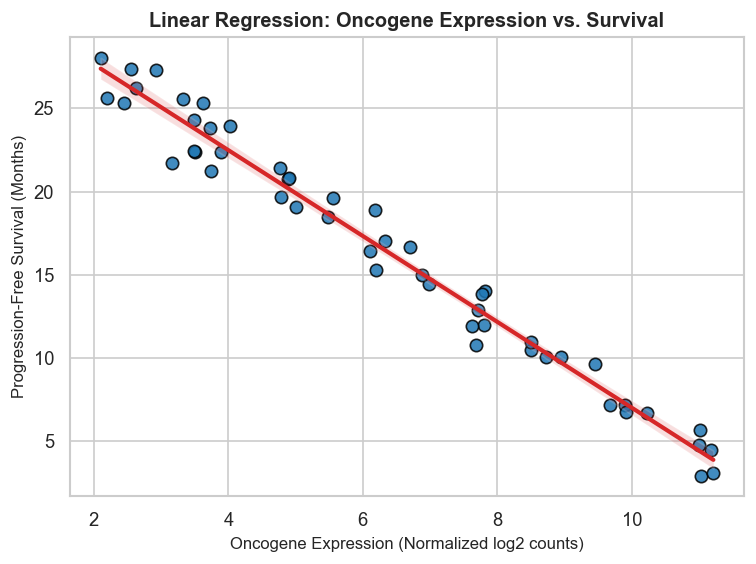



=== Simple Linear Regression Results ===
Learned Weight / Slope (w):     -2.58
Learned Baseline Intercept (b): 32.80

Model Equation:
  Survival = (-2.58 × Expression) + 32.80


In [85]:
# Plot data points and regression line using Seaborn
sns.regplot(
    x=X_oncogene,
    y=y_survival,
    scatter_kws={
        'color': '#1f77b4',
        'edgecolor': 'black',
        's': 55,
        'alpha': 0.85
    },
    line_kws={
        'color': '#d62728',
        'lw': 2.5
    }
)

plt.title(
    "Linear Regression: Oncogene Expression vs. Survival",
    fontsize=12,
    fontweight='bold'
)
plt.xlabel("Oncogene Expression (Normalized log2 counts)", fontsize=10)
plt.ylabel("Progression-Free Survival (Months)", fontsize=10)
plt.tight_layout()
plt.show()


# 2. Extract learned slope (w) and intercept (b)
w = linear_reg_1d.coef_[0]
b = linear_reg_1d.intercept_

print("\n\n=== Simple Linear Regression Results ===")
print(f"Learned Weight / Slope (w):     {w:.2f}")
print(f"Learned Baseline Intercept (b): {b:.2f}")
print(f"\nModel Equation:")
print(f"  Survival = ({w:.2f} × Expression) + {b:.2f}")


---

## 1.2 Multiple Linear Regression (Multi-Gene: `TP53`, `BRCA1`, `MYC`)

As explained in the theory primer, clinical outcomes in bioinformatics are governed by multiple genes simultaneously. We now add 2 more genes, giving us a panel of 3 key biomarkers:
* **`TP53`**: Tumor suppressor gene (loss-of-function mutation / high aberrant expression → reduced survival, negative weight $w < 0$)
* **`BRCA1`**: DNA repair gene (intact activity / higher expression → protective, positive weight $w > 0$)
* **`MYC`**: Oncogene driver (amplification → aggressive tumor, negative weight $w < 0$)

Model equation:
$$\text{Survival} = w_1 \cdot \text{TP53} + w_2 \cdot \text{BRCA1} + w_3 \cdot \text{MYC} + b$$


### Step 4: Add 2 More Genes (`TP53`, `BRCA1`, `MYC`)
We generate a multi-gene cohort for 60 patients using `np.random` reflecting the biological weights from the theory primer:
$$\text{Survival} = (-3.2 \times \text{TP53}) + (1.8 \times \text{BRCA1}) + (-2.5 \times \text{MYC}) + 40.0 + \text{noise}$$


In [86]:
# Generate expression levels for 60 patients across 3 genes
n_patients = 60
tp53_expr = np.random.uniform(1.5, 11.5, size=n_patients)
brca1_expr = np.random.uniform(1.0, 7.0, size=n_patients)
myc_expr = np.random.uniform(1.0, 9.0, size=n_patients)

# Generate biological survival times using the theory weights
noise_multi = np.random.normal(0, 1.5, size=n_patients)
survival_multi = (-3.2 * tp53_expr) + (1.8 * brca1_expr) + (-2.5 * myc_expr) + 40.0 + noise_multi

# Put into a clean pandas DataFrame
multi_gene_df = pd.DataFrame({
    'TP53': tp53_expr,
    'BRCA1': brca1_expr,
    'MYC': myc_expr
})

print(f"Multi-gene dataset created: {n_patients} patients")
print("\nFirst 5 patient records:")
print(multi_gene_df.head(5).round(2))


Multi-gene dataset created: 60 patients

First 5 patient records:
   TP53  BRCA1   MYC
0  1.75   2.43  6.20
1  2.58   5.37  7.79
2  1.81   3.21  6.26
3  7.86   4.79  5.55
4  4.64   4.80  1.75


### Step 5: Apply Linear Regression (`fit`, `predict`)
We fit multiple linear regression on the 3-gene dataset and inspect the learned coefficients.


In [87]:
# 1. Initialize and fit multiple linear regression
multi_reg = LinearRegression()
multi_reg.fit(multi_gene_df, survival_multi)


# prepare one random patient
random_patient = [[2.9, 4.9, 7.9]]

# Predict survival
predicted_survival = multi_reg.predict(random_patient)[0]

print("Random Patient:")
print(random_patient)

print(f"\nPredicted Survival: {predicted_survival:.1f} months")


Random Patient:
[[2.9, 4.9, 7.9]]

Predicted Survival: 19.9 months


/Users/boss/Conda/miniconda3/envs/gcu-aiml-bioinfo/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 6: Show Plot, Equation, and Coefficients
We visualize:
1. **Biomarker Weights Bar Plot:** Green for protective ($w > 0$), Red for risk factors ($w < 0$).
2. **Actual vs. Predicted Plot:** Comparing model predictions to actual patient survival times.


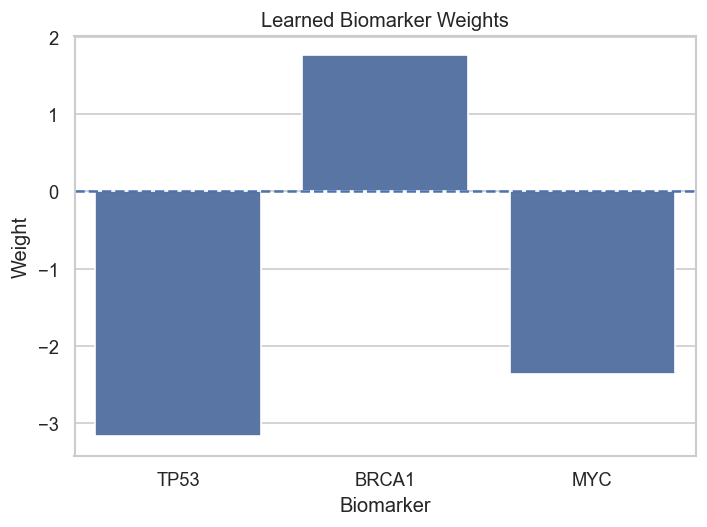

Biological Interpretation:
TP53 (-3.17) & MYC (-2.36): Negative weights → Risk factors
BRCA1 (+1.76): Positive weight → Protective factor
=== Learned Multiple Regression Parameters ===
  TP53  weight (w): -3.17
  BRCA1 weight (w): +1.76
  MYC   weight (w): -2.36
  Baseline Intercept (b): 39.05

Model Equation:
  Survival = (-3.17 × TP53) + (+1.76 × BRCA1) + (-2.36 × MYC) + 39.05


In [88]:
plt.figure(figsize=(6, 4.5))

sns.barplot(
    x=multi_gene_df.columns,
    y=weights
)

plt.axhline(0, linestyle='--')
plt.title("Learned Biomarker Weights")
plt.xlabel("Biomarker")
plt.ylabel("Weight")

plt.tight_layout()
plt.show()

print("Biological Interpretation:")
print(f"TP53 ({weights[0]:+.2f}) & MYC ({weights[2]:+.2f}): Negative weights → Risk factors")
print(f"BRCA1 ({weights[1]:+.2f}): Positive weight → Protective factor")

# 2. Extract learned coefficients (weights) and intercept
weights = multi_reg.coef_
intercept_multi = multi_reg.intercept_

print("=== Learned Multiple Regression Parameters ===")
for gene_name, weight_val in zip(multi_gene_df.columns, weights):
    print(f"  {gene_name:5s} weight (w): {weight_val:+.2f}")
print(f"  Baseline Intercept (b): {intercept_multi:.2f}")

print("\nModel Equation:")
print(f"  Survival = ({weights[0]:+.2f} × TP53) + ({weights[1]:+.2f} × BRCA1) + ({weights[2]:+.2f} × MYC) + {intercept_multi:.2f}")


---

# 2. Polynomial Regression

## Concept: When Biology Curves
In pharmacological and biochemical experiments, relationships are rarely straight lines. Instead, they exhibit **saturation kinetics**:
* **Pharmacological Dose-Response:** At very low drug concentrations, cell viability stays near $100\%$. At medium doses, viability drops rapidly. At high doses, receptor saturation occurs, and viability flattens near $0\%$.

A straight line cannot bend to capture these plateaus. **Polynomial regression** solves this by creating new power features:
$$x \longrightarrow [x, \; x^2, \; x^3]$$

The model fits standard linear regression on the expanded features:
$$\text{Viability} = w_1 \cdot x + w_2 \cdot x^2 + w_3 \cdot x^3 + b$$


### Step 1: Create a Curved Dataset (Dose-Response Assay)
We simulate 40 drug concentration assays ($0.1$ to $10.0\,\mu\text{M}$) measuring cancer cell viability ($0$ to $100\%$), following the theory primer table values.


In [89]:
# Generate drug concentration values from 0.1 to 10.0 μM
drug_conc = np.linspace(0.1, 10.0, 40)

# S-shaped curved dose-response with biological saturation + noise
true_viability = 100.0 / (1.0 + (drug_conc / 3.5)**2.5)
dose_noise = np.random.normal(0, 3.0, size=len(drug_conc))
cell_viability = np.clip(true_viability + dose_noise, 0.0, 100.0)

# Reshape for Scikit-learn
X_dose = drug_conc.reshape(-1, 1)
y_viability = cell_viability

print(f"Curved dose-response dataset created: {len(X_dose)} assays")
print("\nFirst 5 measurements:")
for i in range(5):
    print(f"  Drug Conc = {X_dose[i][0]:.2f} μM -> Cell Viability = {y_viability[i]:.1f}%")


Curved dose-response dataset created: 40 assays

First 5 measurements:
  Drug Conc = 0.10 μM -> Cell Viability = 100.0%
  Drug Conc = 0.35 μM -> Cell Viability = 99.7%
  Drug Conc = 0.61 μM -> Cell Viability = 95.8%
  Drug Conc = 0.86 μM -> Cell Viability = 98.5%
  Drug Conc = 1.12 μM -> Cell Viability = 95.2%


### Step 2: Apply Polynomial Regression (`fit`, `predict`)
We use `PolynomialFeatures(degree=3)` to transform $x \to [x, x^2, x^3]$, then fit `LinearRegression`.


In [90]:
# 1. Transform single feature x into [x, x^2, x^3]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_dose)

# 2. Fit Linear Regression on the expanded polynomial features
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_viability)

# Also fit a simple straight line (degree 1) to compare
simple_line = LinearRegression()
simple_line.fit(X_dose, y_viability)

# 3. Extract learned polynomial coefficients
w_poly = poly_reg.coef_
b_poly = poly_reg.intercept_

print("=== Polynomial Regression (Degree 3) Parameters ===")
print(f"w1 (linear term x):     {w_poly[0]:+.4f}")
print(f"w2 (squared term x²):   {w_poly[1]:+.4f}")
print(f"w3 (cubic term x³):     {w_poly[2]:+.4f}")
print(f"Intercept (b):          {b_poly:.2f}")

print("\nModel Equation:")
print(f"  Viability = ({w_poly[0]:+.2f} × conc) + ({w_poly[1]:+.3f} × conc²) + ({w_poly[2]:+.4f} × conc³) + {b_poly:.2f}")


=== Polynomial Regression (Degree 3) Parameters ===
w1 (linear term x):     -16.8435
w2 (squared term x²):   -0.1446
w3 (cubic term x³):     +0.0855
Intercept (b):          109.41

Model Equation:
  Viability = (-16.84 × conc) + (-0.145 × conc²) + (+0.0855 × conc³) + 109.41


### Step 3: Show Plot and Equation
We plot the original assay data, the straight line (underfitting), and the polynomial curve that captures the biological saturation effect.


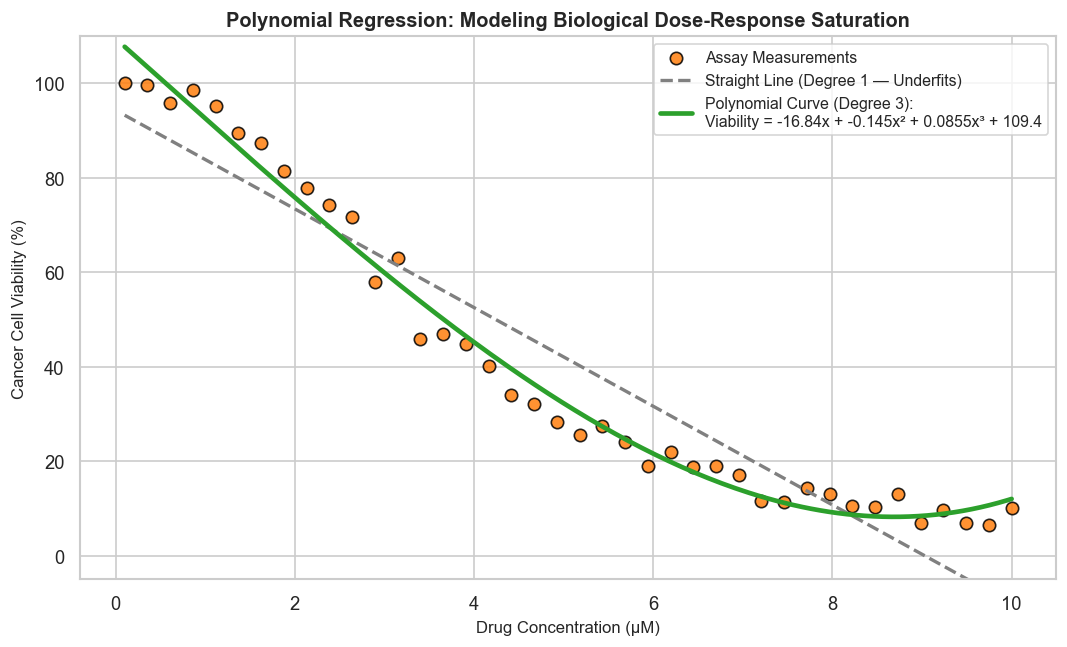

Key Takeaways:
  1. The straight line fails to capture biological plateaus (underfitting).
  2. Synthetically expanding features x -> [x, x², x³] allows standard linear regression to model complex biological saturation!


In [91]:
# Dense grid for drawing smooth curves
dense_conc = np.linspace(0.1, 10.0, 200).reshape(-1, 1)
dense_poly = poly.transform(dense_conc)

# Predictions
pred_curve = poly_reg.predict(dense_poly)
pred_straight = simple_line.predict(dense_conc)

plt.figure(figsize=(9, 5.5))

# Plot actual laboratory assay data points
plt.scatter(X_dose, y_viability, color='#ff7f0e', edgecolor='black', s=55, alpha=0.85, label='Assay Measurements')

# Plot straight line (underfitting)
plt.plot(dense_conc, pred_straight, color='gray', linestyle='--', lw=2, label='Straight Line (Degree 1 — Underfits)')

# Plot polynomial curve (optimal biological fit)
plt.plot(dense_conc, pred_curve, color='#2ca02c', lw=2.8,
         label=f'Polynomial Curve (Degree 3):\nViability = {w_poly[0]:.2f}x + {w_poly[1]:.3f}x² + {w_poly[2]:.4f}x³ + {b_poly:.1f}')

plt.title("Polynomial Regression: Modeling Biological Dose-Response Saturation", fontsize=12, fontweight='bold')
plt.xlabel("Drug Concentration (μM)", fontsize=10)
plt.ylabel("Cancer Cell Viability (%)", fontsize=10)
plt.ylim(-5, 110)
plt.legend(frameon=True, fontsize=9.5, loc='upper right')
plt.tight_layout()
plt.show()

print("Key Takeaways:")
print("  1. The straight line fails to capture biological plateaus (underfitting).")
print("  2. Synthetically expanding features x -> [x, x², x³] allows standard linear regression to model complex biological saturation!")


---

## 📌 Takeaway Deliverable (Submit via GitHub Issues)

Complete the exercise below and submit your work:
1. Open the course GitHub repository in your browser.
2. Navigate to the **Issues** tab $\longrightarrow$ click **New Issue**.
3. Title your issue: `[Takeaway] <Student Name> - Linear & Polynomial Regression`
4. Post:
   * A short code snippet applying either simple/multiple regression or polynomial regression.
   * The learned equation.
   * A 2-sentence biological interpretation of your learned weights or curve.
